# Experimental analysis of V-BReE performance under extended variance threshold (EVT) conditions
During primary data collection analysis, a positive relationship between error rate and accuracy differential between V-BReE and GPT-OSS-20b, the highest performance constituent model during testing, was noted.  It is hypothesized that errors effectively reset the variance, allowing the ensemble to process the responses for longer and arrive at higher quality final responses.

To investigate this hypothesis, a sub-sample containing 360 items that were answered correctly and without processing errors during  initial analysis and 360 items that were answered incorrectly and without processing errors during initial analysis was generated.  This subset of 720 total questions was processed using extended variance threshold settings (initial threshold = 2, scaling factor = 1.05) that allow for more processing cycles.  This analysis examines the resulting data to look for both positive and negative effects that might have come out of this change.

In [1]:
# %pip install scipy

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns

## Load and prepare data
The following data sets are loaded for independent and comparative analysis:
- Extended variance threshold sub-sample data - all responses
- Extended variance threshold sub-sample data - selected responses
- Single model response data for all constituent models
    - openai/gpt-oss-20b:groq
    - Qwen/Qwen2.5-7B-Instruct:together
    - meta-llama/Llama-3.1-8B-Instruct:cerebras

In [2]:
##EVT = EXTENDED VARIANCE THRESHOLD DATA

##==========================
##= RAW RESPONSE DATA SETS =
##==========================
##ORIGINAL VBREE TESTING DATA
vbree_responses = pd.read_csv('data/full_sample_results/v-bree_mmlupro_test_0_3000_20260306_final.csv')

##ORIGINAL INDIVDIUAL MODEL TESTING DATA 
gpt_responses = pd.read_csv('data/full_sample_results/gpt_mmlupro_test_0_3000_20260306.csv')
llama_responses = pd.read_csv('data/full_sample_results/llama_mmlupro_test_0_3000_20260307.csv')
qwen_responses = pd.read_csv('data/full_sample_results/qwen_mmlupro_test_0_3000_20260307.csv')

##PRIMARY SAMPLE, FOR CORRECT ANSWER MERGE
sample = pd.read_csv('data/mmlu_pro_12_cat_250_sample_20260306.csv')

##EVT DATA SET
vbree_evt_resp = pd.read_csv('data/variance_threshold_testing_data/vbree_mmlupro_var_thresh_testing_20260401.csv')
vbree_evt_slct_resp = pd.read_csv('data/variance_threshold_testing_data/vbree_mmlupro_var_thresh_testing_selected_20260401.csv')


##=================================
##= MERGED WITH ANSWERS DATA SETS =
##=================================
##ALIGN CORRECT ANSWERS WITH SINGLE-MODEL DATA
vbree_all_resp = pd.merge(vbree_responses, sample[['question_id', 'answer']], left_on = "id", right_on = "question_id", how = "left")
vbree_evt_all_resp = pd.merge(vbree_evt_resp, sample[['question_id', 'answer']], left_on = "id", right_on = "question_id", how = "left")



##================================
##= SELECTED RESPONSES DATA SETS =
##================================
##ALIGN CORRECT ANSWERS WITH SINGLE-MODEL DATA
vbree_selected_resp = vbree_all_resp[vbree_all_resp['chosen_response'] == True]
gpt_selected_resp = pd.merge(gpt_responses, sample[['question_id', 'answer']], left_on = "id", right_on = "question_id", how = "left")
llama_selected_resp = pd.merge(llama_responses, sample[['question_id', 'answer']], left_on = "id", right_on = "question_id", how = "left")
qwen_selected_resp = pd.merge(qwen_responses, sample[['question_id', 'answer']], left_on = "id", right_on = "question_id", how = "left")

##LOAD EVT SELECTED DATA SET (ALREADY MERGED WITH ANSWERS)
vbree_evt_selected_resp = pd.merge(vbree_evt_slct_resp, sample[['question_id', 'answer']], left_on = "id", right_on = "question_id", how = "left")



##=====================================
##= FILTER DATA SETS TO EVT SUBSAMPLE =
##=====================================
evt_subsample_ids = vbree_evt_selected_resp['id'].unique().tolist()  ##IDS USED IN SUBSAMPLE

##ALL RESPONSES
vbree_subsmpl_all_resp = vbree_all_resp[vbree_all_resp['id'].isin(evt_subsample_ids)]
vbree_evt_subsmpl_all_resp = vbree_evt_all_resp ##CONVENIENCE ALIAS, ALREADY FILTERED TO SUBSAMPLE

##SELECTED RESPONSES
vbree_subsmpl_selected_resp = vbree_selected_resp[vbree_selected_resp['id'].isin(evt_subsample_ids)]
gpt_subsmpl_selected_resp = gpt_selected_resp[gpt_selected_resp['id'].isin(evt_subsample_ids)]
llama_subsmpl_selected_resp = llama_selected_resp[llama_selected_resp['id'].isin(evt_subsample_ids)]
qwen_subsmpl_selected_resp = qwen_selected_resp[qwen_selected_resp['id'].isin(evt_subsample_ids)]
vbree_evt_subsmpl_selected_resp = vbree_evt_selected_resp ##CONVENIENCE ALIAS, ALREADY FILTERED TO SUBSAMPLE

In [3]:
print(vbree_evt_subsmpl_all_resp["id"].nunique())

360


## EVT Accuracy

In [4]:
evt_accuracy = (vbree_evt_selected_resp["selected_choice"] == vbree_evt_selected_resp["answer"]).mean()

print(f"V-BReE EVT Subsample Selected Accuracy: {evt_accuracy}")

V-BReE EVT Subsample Selected Accuracy: 0.5722222222222222


## Origin results accuracy - V-BReE and all constituent models

In [5]:
vbree_subsmpl_selected_resp_acc = (vbree_subsmpl_selected_resp["selected_choice"] == vbree_subsmpl_selected_resp["answer"]).mean()
gpt_subsmpl_selected_resp_acc = (gpt_subsmpl_selected_resp["selected_choice"] == gpt_subsmpl_selected_resp["answer"]).mean()
llama_subsmpl_selected_resp_acc = (llama_subsmpl_selected_resp["selected_choice"] == llama_subsmpl_selected_resp["answer"]).mean()
qwen_subsmpl_selected_resp_acc = (qwen_subsmpl_selected_resp["selected_choice"] == qwen_subsmpl_selected_resp["answer"]).mean()

print(f"V-BReE Selected Accuracy: {vbree_subsmpl_selected_resp_acc}")
print(f"GPT Selected Accuracy: {gpt_subsmpl_selected_resp_acc}")
print(f"LLaMA Selected Accuracy: {llama_subsmpl_selected_resp_acc}")
print(f"Qwen Selected Accuracy: {qwen_subsmpl_selected_resp_acc}")

V-BReE Selected Accuracy: 0.5
GPT Selected Accuracy: 0.6027777777777777
LLaMA Selected Accuracy: 0.36944444444444446
Qwen Selected Accuracy: 0.4861111111111111


## Check statistical significance of difference between base and EVT processing
*Google Gemini used as a guide on this procedure*


The appropriate test for significance when testing a matched pairs on a dichotomous variable is McNemar's Test (https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/mcnemars-test/).

In [6]:
base_success_ids = vbree_subsmpl_selected_resp[vbree_subsmpl_selected_resp["selected_choice"] == vbree_subsmpl_selected_resp["answer"]]
base_failure_ids = vbree_subsmpl_selected_resp[vbree_subsmpl_selected_resp["selected_choice"] != vbree_subsmpl_selected_resp["answer"]]
evt_success_ids = vbree_evt_subsmpl_selected_resp[vbree_evt_subsmpl_selected_resp["selected_choice"] == vbree_evt_subsmpl_selected_resp["answer"]]
evt_failure_ids = vbree_evt_subsmpl_selected_resp[vbree_evt_subsmpl_selected_resp["selected_choice"] != vbree_evt_subsmpl_selected_resp["answer"]]

base_success_evt_failures_df = pd.merge(base_success_ids, evt_failure_ids, on = "id", how = "inner")
base_failure_evt_successes_df = pd.merge(base_failure_ids, evt_success_ids, on = "id", how = "inner")

base_success_evt_failure_count = len(base_success_evt_failures_df)
base_failure_evt_success_count = len(base_failure_evt_successes_df)

mcnemar_result = stats.binomtest(base_success_evt_failure_count, n = base_success_evt_failure_count + base_failure_evt_success_count, p = 0.5, alternative = "two-sided")

print(f"Baseline Success & EVT Failure Count: {base_success_evt_failure_count}")
print(f"Baseline Failure & EVT Success Count: {base_failure_evt_success_count}")

print(f"McNemar P-Value: {mcnemar_result.pvalue}")

Baseline Success & EVT Failure Count: 17
Baseline Failure & EVT Success Count: 43
McNemar P-Value: 0.0010657657791434353


## Plot accuracy for base and EVT subsamples

EVT vs Baseline Accuracy Comparison:
             Model  Accuracy
0  V-BReE Baseline  0.500000
1       V-BReE EVT  0.572222


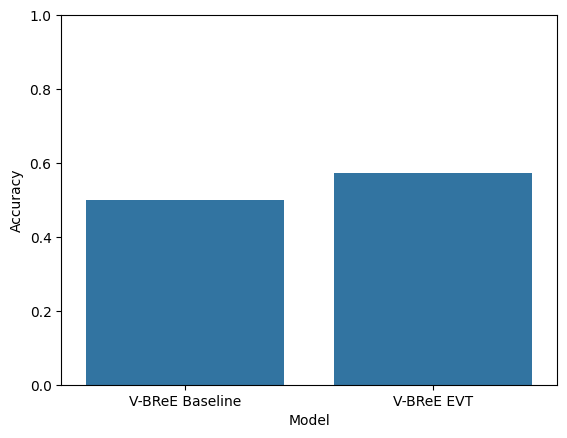

In [7]:
##PLOT ACCURACY COMPARISON OF EVT VS BASELINE
accuracy_data = pd.DataFrame({
    "Model": ["V-BReE Baseline", "V-BReE EVT"],
    "Accuracy": [vbree_subsmpl_selected_resp_acc, evt_accuracy]
})
sns.barplot(x = "Model", y = "Accuracy", data = accuracy_data)
plt.ylim(0, 1)

print("EVT vs Baseline Accuracy Comparison:")
print(accuracy_data)

## EVT Accuracy by domain

EVT vs Baseline Accuracy Comparison by Domain:
              domain  accuracy            Model
0           Business  0.500000  V-BReE Baseline
1            Biology  0.500000  V-BReE Baseline
2   Computer science  0.500000  V-BReE Baseline
3        Engineering  0.500000  V-BReE Baseline
4               Math  0.500000  V-BReE Baseline
5          Chemistry  0.500000  V-BReE Baseline
6            Physics  0.500000  V-BReE Baseline
7            History  0.500000  V-BReE Baseline
8         Psychology  0.500000  V-BReE Baseline
9          Economics  0.500000  V-BReE Baseline
10        Philosophy  0.500000  V-BReE Baseline
11               Law  0.500000  V-BReE Baseline
0           Business  0.700000       V-BReE EVT
1            Biology  0.666667       V-BReE EVT
2   Computer science  0.633333       V-BReE EVT
3        Engineering  0.633333       V-BReE EVT
4               Math  0.633333       V-BReE EVT
5          Chemistry  0.600000       V-BReE EVT
6            Physics  0.600000       V-BR

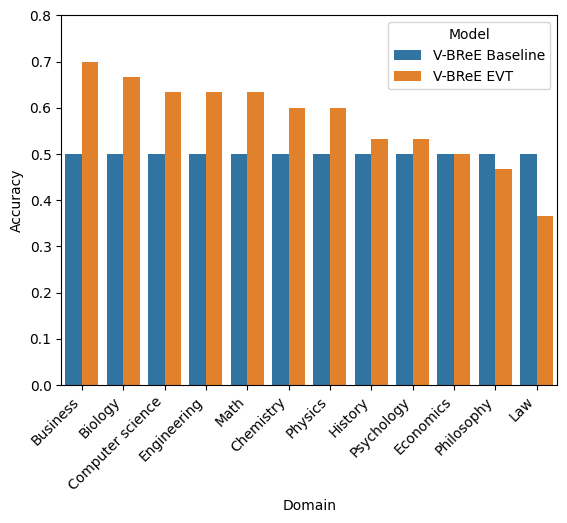

In [16]:
##UPDATE DOMAIN TO CAPITALIZE
vbree_subsmpl_selected_resp["domain"] = vbree_subsmpl_selected_resp["domain"].str.capitalize()
vbree_evt_subsmpl_selected_resp["domain"] = vbree_evt_subsmpl_selected_resp["domain"].str.capitalize()

##SORT BOTH BY EVT SUBSAMPLE ACCURACY
sort_order = vbree_evt_subsmpl_selected_resp.groupby("domain").apply(lambda x: (x["selected_choice"] == x["answer"]).mean()).sort_values(ascending = False).index.tolist()
vbree_subsmpl_selected_resp["domain"] = pd.Categorical(vbree_subsmpl_selected_resp["domain"], categories = sort_order, ordered = True)
vbree_evt_subsmpl_selected_resp["domain"] = pd.Categorical(vbree_evt_subsmpl_selected_resp["domain"], categories = sort_order, ordered = True)

##EVT ACCURACY BY DOMAIN
evt_cat_acc = vbree_evt_subsmpl_selected_resp.groupby("domain").apply(lambda x: (x["selected_choice"] == x["answer"]).mean()).reset_index(name = "accuracy")
evt_cat_acc["Model"] = "V-BReE EVT"

##COMPARE DOMAIN-SPECIFIC ACCURACY OF EVT VS BASELINE
base_cat_acc = vbree_subsmpl_selected_resp.groupby("domain").apply(lambda x: (x["selected_choice"] == x["answer"]).mean()).reset_index(name = "accuracy")
base_cat_acc["Model"] = "V-BReE Baseline"

combined_cat_acc = pd.concat([base_cat_acc, evt_cat_acc])
sns.barplot(x = "domain", y = "accuracy", hue = "Model", data = combined_cat_acc)
plt.xticks(rotation = 45, ha = "right")
plt.ylabel("Accuracy")
plt.xlabel("Domain")
plt.ylim(0, .8)

print("EVT vs Baseline Accuracy Comparison by Domain:")
print(combined_cat_acc)

## Calculate percent improvement

In [9]:
##PERCENT IMPROVEMENT OF EVT OVER BASELINE - OVERALL AND BY DOMAIN
accuracy_pct_change = ((evt_accuracy - vbree_subsmpl_selected_resp_acc) / vbree_subsmpl_selected_resp_acc) * 100
print(f"Overall Percent Improvement of EVT over Baseline: {accuracy_pct_change:.2f}%")

combined_cat_acc_pivot = combined_cat_acc.pivot(index = "domain", columns = "Model", values = "accuracy").reset_index()
combined_cat_acc_pivot["Percent Improvement"] = ((combined_cat_acc_pivot["V-BReE EVT"] - combined_cat_acc_pivot["V-BReE Baseline"]) / combined_cat_acc_pivot["V-BReE Baseline"]) * 100
print(combined_cat_acc_pivot[["domain", "Percent Improvement"]])

Overall Percent Improvement of EVT over Baseline: 14.44%
Model            domain  Percent Improvement
0               biology            33.333333
1              business            40.000000
2             chemistry            20.000000
3      computer science            26.666667
4             economics             0.000000
5           engineering            26.666667
6               history             6.666667
7                   law           -26.666667
8                  math            26.666667
9            philosophy            -6.666667
10              physics            20.000000
11           psychology             6.666667


## Comparing GPT accuracy to EVT accuracy by domain

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'biology'),
  Text(1, 0, 'business'),
  Text(2, 0, 'chemistry'),
  Text(3, 0, 'computer science'),
  Text(4, 0, 'economics'),
  Text(5, 0, 'engineering'),
  Text(6, 0, 'history'),
  Text(7, 0, 'law'),
  Text(8, 0, 'math'),
  Text(9, 0, 'philosophy'),
  Text(10, 0, 'physics'),
  Text(11, 0, 'psychology')])

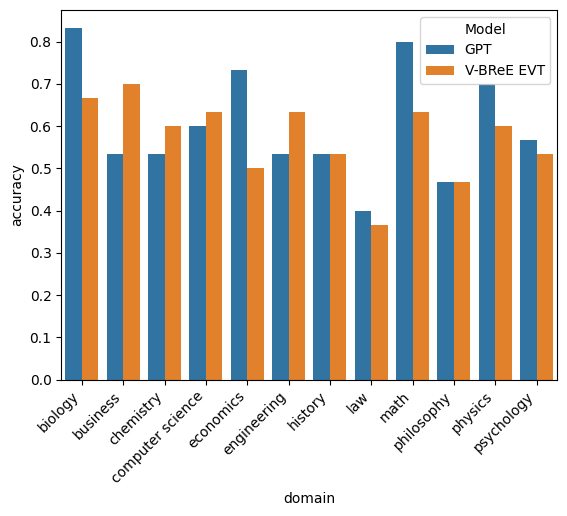

In [10]:
##COMPARE GPT ACCURACY TO EVT ACCURACY BY DOMAIN
gpt_cat_acc = gpt_subsmpl_selected_resp.groupby("domain").apply(lambda x: (x["selected_choice"] == x["answer"]).mean()).reset_index(name = "accuracy")
gpt_cat_acc["Model"] = "GPT"

gpt_evt_cat_acc_gpt = pd.concat([gpt_cat_acc, evt_cat_acc])
sns.barplot(x = "domain", y = "accuracy", hue = "Model", data = gpt_evt_cat_acc_gpt)
plt.xticks(rotation = 45, ha = "right")

## EVT error percentages and rates vs Baseline

In [11]:
##IDS WITH ERROR ANSWERS IN EVT
evt_error_ids = vbree_evt_subsmpl_all_resp[vbree_evt_subsmpl_all_resp["updated_answer"] == "Error"]["id"].unique()
evt_error_pct = len(evt_error_ids) / vbree_evt_subsmpl_all_resp["id"].nunique()
print(f"Percentage of Processed Prompts with Errors in the Cycle: {evt_error_pct:.2%}")

##OVERALL ERROR RATE
evt_error_rate = (vbree_evt_subsmpl_all_resp["updated_answer"] == "Error").mean()
print(f"EVT Overall Error Rate: {evt_error_rate:.2%}")

print("=====================")

##IDS WITH ERROR ANSWERS IN BASELINE
base_error_ids = vbree_responses[vbree_responses["updated_answer"] == "Error"]["id"].unique()
base_error_pct = len(base_error_ids) / vbree_responses["id"].nunique()
print(f"Baseline Overall Error Rate: {base_error_pct:.2%}")

base_error_rate = (vbree_responses["updated_answer"] == "Error").mean()
print(f"Baseline Overall Error Rate: {base_error_rate:.2%}")

Percentage of Processed Prompts with Errors in the Cycle: 30.00%
EVT Overall Error Rate: 1.10%
Baseline Overall Error Rate: 29.43%
Baseline Overall Error Rate: 4.60%


## Confidence score performance by accuracy